# ARTI 404 - Image Denoising Using Spatial and Frequency Domain Methods

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

Dateset setup 

In [12]:
DATASET = "/home/zainab/image assignment"
image_names = [
    "camera",
    "coins",
    "text",
    "rice",
    "astronaut"
]

loading  image 

In [5]:

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")

    # Convert OpenCV BGR to RGB for color images
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img

Evaluation metrics

In [6]:
def evaluate(clean, denoised):
    psnr_value = psnr(clean, denoised, data_range=255)

    if len(clean.shape) == 3:
        ssim_value = ssim(clean, denoised, channel_axis=-1, data_range=255)
    else:
        ssim_value = ssim(clean, denoised, data_range=255)

    return psnr_value, ssim_value


Spatial Domain Denoising

In [7]:
def spatial_denoising(img, method="median", kernel_size=5):

    if method == "median":
        return cv2.medianBlur(img, kernel_size)

    elif method == "gaussian":
        return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

    elif method == "mean":
        return cv2.blur(img, (kernel_size, kernel_size))

    else:
        raise ValueError("Unknown spatial method")


Gaussian Low Pass Filter

In [8]:
def gaussian_lowpass_filter(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    u = np.arange(rows)
    v = np.arange(cols)

    V, U = np.meshgrid(v, u)

    distance_squared = (U - crow) ** 2 + (V - ccol) ** 2

    H = np.exp(-distance_squared / (2 * cutoff ** 2))

    return H


Frequency Domain Filtering 

In [9]:
def frequency_gaussian_denoising_gray(img_gray, cutoff=40):
    img_float = img_gray.astype(np.float32)

    F = np.fft.fft2(img_float)
    F_shifted = np.fft.fftshift(F)

    H = gaussian_lowpass_filter(img_gray.shape, cutoff)

    G_shifted = F_shifted * H

    G = np.fft.ifftshift(G_shifted)

    img_filtered = np.fft.ifft2(G)
    img_filtered = np.real(img_filtered)

    img_filtered = np.clip(img_filtered, 0, 255)

    return img_filtered.astype(np.uint8)


def frequency_gaussian_denoising(img, cutoff=40):

    if len(img.shape) == 2:
        return frequency_gaussian_denoising_gray(img, cutoff)

    channels = []

    for c in range(img.shape[2]):
        filtered_channel = frequency_gaussian_denoising_gray(
            img[:, :, c],
            cutoff
        )
        channels.append(filtered_channel)

    return np.stack(channels, axis=2)


Parameter Tuning

In [10]:
spatial_method = "median"

spatial_kernel_sizes = [3, 5, 7]
frequency_cutoffs = [20, 40, 80]

results = []

Main Loop


Processing image: camera
Spatial median, kernel=3: PSNR=25.71, SSIM=0.4939
Spatial median, kernel=5: PSNR=26.21, SSIM=0.6040
Spatial median, kernel=7: PSNR=25.48, SSIM=0.6442
Frequency Gaussian, cutoff=20: PSNR=22.57, SSIM=0.6268
Frequency Gaussian, cutoff=40: PSNR=25.04, SSIM=0.6879
Frequency Gaussian, cutoff=80: PSNR=26.94, SSIM=0.6403


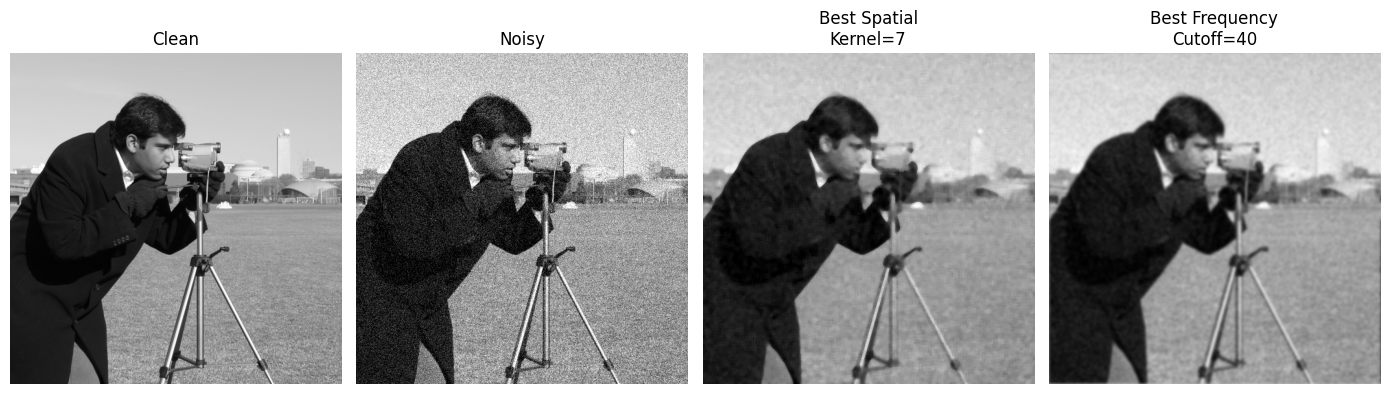


Processing image: coins
Spatial median, kernel=3: PSNR=28.07, SSIM=0.8536
Spatial median, kernel=5: PSNR=26.17, SSIM=0.7710
Spatial median, kernel=7: PSNR=25.12, SSIM=0.7262
Frequency Gaussian, cutoff=20: PSNR=21.61, SSIM=0.5585
Frequency Gaussian, cutoff=40: PSNR=23.38, SSIM=0.5748
Frequency Gaussian, cutoff=80: PSNR=22.50, SSIM=0.4816


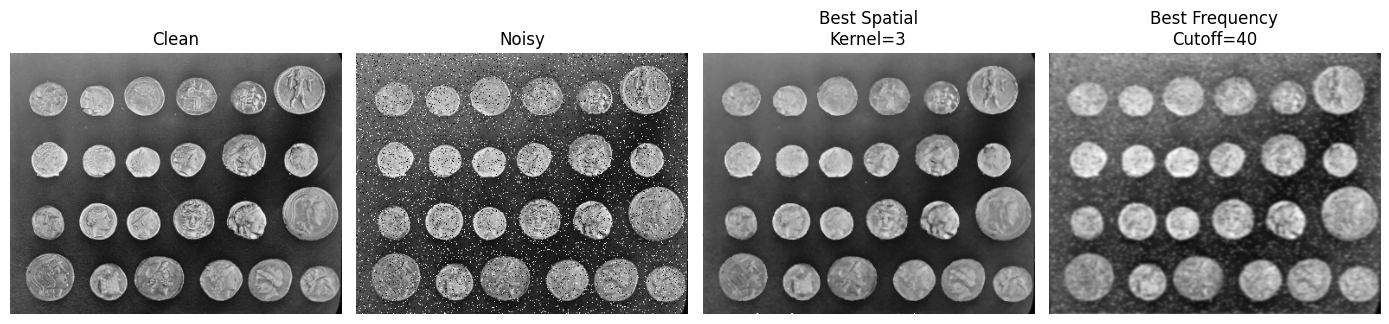


Processing image: text
Spatial median, kernel=3: PSNR=32.01, SSIM=0.9043
Spatial median, kernel=5: PSNR=28.51, SSIM=0.8240
Spatial median, kernel=7: PSNR=25.48, SSIM=0.7166
Frequency Gaussian, cutoff=20: PSNR=25.59, SSIM=0.6524
Frequency Gaussian, cutoff=40: PSNR=25.33, SSIM=0.5466
Frequency Gaussian, cutoff=80: PSNR=21.26, SSIM=0.3501


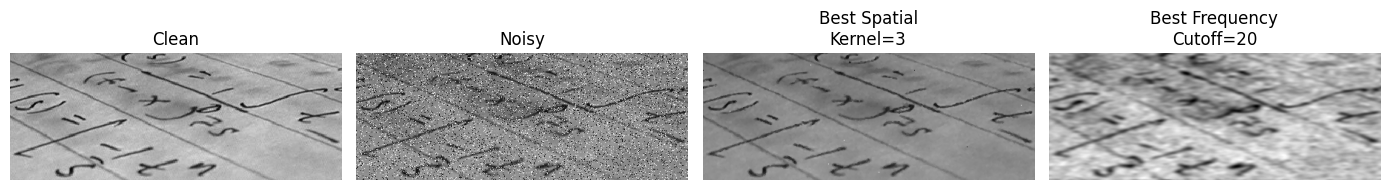


Processing image: rice
Spatial median, kernel=3: PSNR=23.03, SSIM=0.4602
Spatial median, kernel=5: PSNR=23.78, SSIM=0.5393
Spatial median, kernel=7: PSNR=23.34, SSIM=0.5659
Frequency Gaussian, cutoff=20: PSNR=22.02, SSIM=0.5731
Frequency Gaussian, cutoff=40: PSNR=24.14, SSIM=0.6168
Frequency Gaussian, cutoff=80: PSNR=23.75, SSIM=0.5054


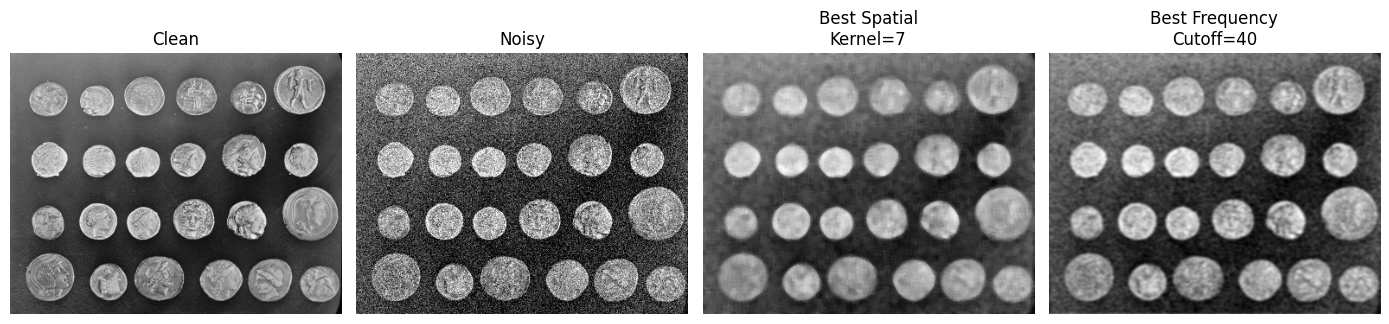


Processing image: astronaut
Spatial median, kernel=3: PSNR=30.32, SSIM=0.9375
Spatial median, kernel=5: PSNR=27.59, SSIM=0.8926
Spatial median, kernel=7: PSNR=25.71, SSIM=0.8461
Frequency Gaussian, cutoff=20: PSNR=19.82, SSIM=0.5283
Frequency Gaussian, cutoff=40: PSNR=22.33, SSIM=0.6044
Frequency Gaussian, cutoff=80: PSNR=22.84, SSIM=0.5150


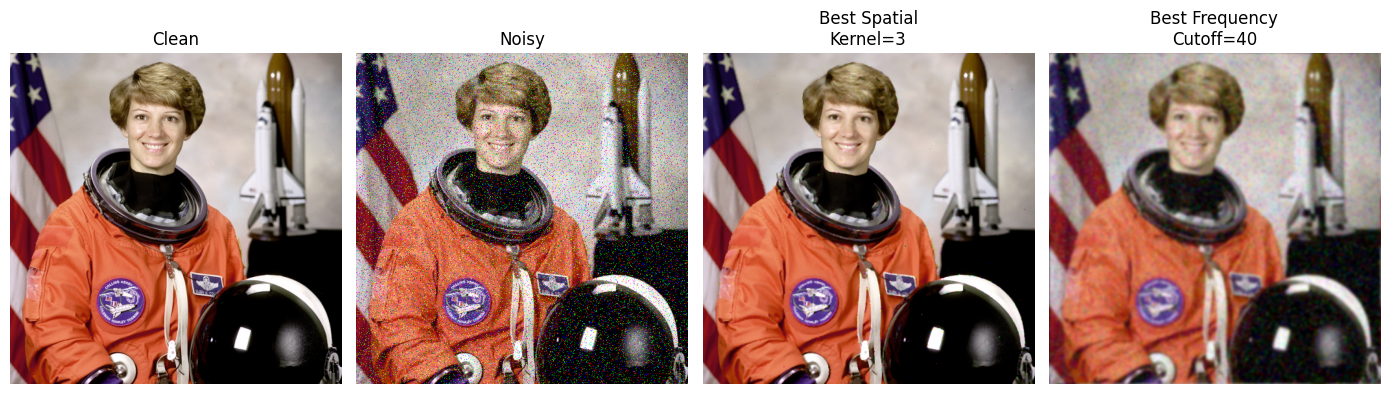

In [13]:
for name in image_names:

    clean_path = os.path.join(
        DATASET,
        "clean",
        f"{name}.png"
    )

    noisy_path = os.path.join(
        DATASET,
        "noisy",
        f"{name}_noisy.png"
    )

    clean = load_image(clean_path)
    noisy = load_image(noisy_path)

    print(f"\nProcessing image: {name}")

    best_spatial = None
    best_spatial_score = -1
    best_spatial_params = None
    best_spatial_metrics = None

    for k in spatial_kernel_sizes:

        denoised_spatial = spatial_denoising(
            noisy,
            method=spatial_method,
            kernel_size=k
        )

        p, s = evaluate(clean, denoised_spatial)

        print(f"Spatial {spatial_method}, kernel={k}: PSNR={p:.2f}, SSIM={s:.4f}")

        if s > best_spatial_score:
            best_spatial_score = s
            best_spatial = denoised_spatial
            best_spatial_params = k
            best_spatial_metrics = (p, s)

    best_frequency = None
    best_frequency_score = -1
    best_frequency_params = None
    best_frequency_metrics = None

    for cutoff in frequency_cutoffs:

        denoised_frequency = frequency_gaussian_denoising(
            noisy,
            cutoff=cutoff
        )

        p, s = evaluate(clean, denoised_frequency)

        print(f"Frequency Gaussian, cutoff={cutoff}: PSNR={p:.2f}, SSIM={s:.4f}")

        if s > best_frequency_score:
            best_frequency_score = s
            best_frequency = denoised_frequency
            best_frequency_params = cutoff
            best_frequency_metrics = (p, s)

    results.append([
        name,
        "Spatial",
        f"{spatial_method}, kernel={best_spatial_params}",
        best_spatial_metrics[0],
        best_spatial_metrics[1]
    ])

    results.append([
        name,
        "Frequency",
        f"Gaussian LPF, cutoff={best_frequency_params}",
        best_frequency_metrics[0],
        best_frequency_metrics[1]
    ])

    cmap = "gray" if len(clean.shape) == 2 else None

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(clean, cmap=cmap)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(noisy, cmap=cmap)
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(best_spatial, cmap=cmap)
    plt.title(f"Best Spatial\nKernel={best_spatial_params}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(best_frequency, cmap=cmap)
    plt.title(f"Best Frequency\nCutoff={best_frequency_params}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

 Final Results Table
 

In [14]:

print("\nFinal Results")
print("-" * 90)
print(f"{'Image':12s} {'Method':12s} {'Parameters':28s} {'PSNR':>10s} {'SSIM':>10s}")
print("-" * 90)

for row in results:
    print(
        f"{row[0]:12s} "
        f"{row[1]:12s} "
        f"{row[2]:28s} "
        f"{row[3]:10.2f} "
        f"{row[4]:10.4f}"
    )




Final Results
------------------------------------------------------------------------------------------
Image        Method       Parameters                         PSNR       SSIM
------------------------------------------------------------------------------------------
camera       Spatial      median, kernel=7                  25.48     0.6442
camera       Frequency    Gaussian LPF, cutoff=40           25.04     0.6879
coins        Spatial      median, kernel=3                  28.07     0.8536
coins        Frequency    Gaussian LPF, cutoff=40           23.38     0.5748
text         Spatial      median, kernel=3                  32.01     0.9043
text         Frequency    Gaussian LPF, cutoff=20           25.59     0.6524
rice         Spatial      median, kernel=7                  23.34     0.5659
rice         Frequency    Gaussian LPF, cutoff=40           24.14     0.6168
astronaut    Spatial      median, kernel=3                  30.32     0.9375
astronaut    Frequency    Gaussia

Average Results


In [15]:
spatial_psnr = [r[3] for r in results if r[1] == "Spatial"]
spatial_ssim = [r[4] for r in results if r[1] == "Spatial"]

frequency_psnr = [r[3] for r in results if r[1] == "Frequency"]
frequency_ssim = [r[4] for r in results if r[1] == "Frequency"]

print("\nAverage Results")
print("-" * 50)
print(f"Spatial Method   : PSNR = {np.mean(spatial_psnr):.2f}, SSIM = {np.mean(spatial_ssim):.4f}")
print(f"Frequency Method : PSNR = {np.mean(frequency_psnr):.2f}, SSIM = {np.mean(frequency_ssim):.4f}")


Average Results
--------------------------------------------------
Spatial Method   : PSNR = 27.84, SSIM = 0.7811
Frequency Method : PSNR = 24.10, SSIM = 0.6273
